# RSNA Pneumonia Detection — Dual-Paradigm B-Spline Contour Optimization
### Unified Framework: Weakly-Supervised Localization (ResNet-50) & Supervised Detection (YOLOv8s)

This research notebook implements and benchmarks the complete dual-paradigm pipeline:

1. **Medical Preprocessing**: HU conversion, Lung Windowing ($\text{WL}=-500, \text{WW}=1500\text{ HU}$), and CLAHE contrast enhancement.
2. **Paradigm A (Classification / WSOL)**:
   - **ResNet-50** backbone trained with positive class loss weighting ($\text{weight} \approx 3.44$).
   - **Grad-CAM & Grad-CAM++** extraction capturing 1st and higher-order gradient heatmaps.
   - **Curvature-Regularized Closed B-Spline Active Contour**: Turns noisy CAM blobs into smooth anatomical boundaries without box labels.
3. **Paradigm B (Object Detection / Refinement)**:
   - **YOLOv8s Object Detector** trained on RSNA bounding box annotations.
   - **B-Spline Active Contour Refinement**: Snaps rigid rectangular boxes to pulmonary opacity margins.
4. **Unified Multi-Paradigm Benchmark**: Quantitative evaluation (Mean IoU, Dice Score, Loc Acc @ 0.3/0.5, Pointing Game) across all baselines and proposed methods.
5. **6-Panel Clinical Visual Gallery**: Side-by-side visual comparison on identical patient cases.


In [23]:
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"
os.environ["MKL_SERVICE_FORCE_INTEL"] = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import logging
import random
from pathlib import Path
from typing import Tuple, List, Dict, Any, Optional

import cv2
import pydicom
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import interpolate
from skimage.filters import gaussian
from skimage.segmentation import active_contour

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("GradCAM_BSpline")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("=" * 65)
print("             ENVIRONMENT & HARDWARE VERIFICATION")
print("=" * 65)
print(f"  PyTorch Version      : {torch.__version__}")
print(f"  torch.cuda.is_available(): {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU Device           : {torch.cuda.get_device_name(0)}")
    print(f"  Total VRAM           : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    DEVICE = torch.device("cuda:0")
else:
    print("  Device               : CPU")
    DEVICE = torch.device("cpu")
print("=" * 65)


             ENVIRONMENT & HARDWARE VERIFICATION
  PyTorch Version      : 2.6.0+cu124
  torch.cuda.is_available(): True
  GPU Device           : NVIDIA GeForce RTX 4060 Laptop GPU
  Total VRAM           : 8.00 GB


In [24]:
# ── Paths & Configuration ───────────────────────────────────────────────────
DATA_DIR          = Path("rsna-pneumonia-detection-challenge")
TRAIN_IMG_DIR     = DATA_DIR / "stage_2_train_images"
TRAIN_LABELS_CSV  = DATA_DIR / "stage_2_train_labels.csv"
CLASS_INFO_CSV    = DATA_DIR / "stage_2_detailed_class_info.csv"

# Preprocessing Constants
IMG_SIZE          = 224    # Native ResNet input size; lower activation memory for 4GB VRAM
WINDOW_LEVEL      = -500   # HU
WINDOW_WIDTH      = 1500   # HU -> [-1250, +250] HU
BATCH_SIZE        = 2      # Conservative physical batch size for ResNet-50 on 4GB VRAM
NUM_WORKERS       = 0      # Set to 0 to avoid PyTorch multiprocessing pickling error in Jupyter
EPOCHS            = 10     # Sufficient for fine-tuning pretrained CNNs

OUTPUT_DIR        = Path("gradcam_bspline_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset root: {DATA_DIR.resolve()}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")


Dataset root: D:\Downloads\ResNet\DPL302m\rsna-pneumonia-detection-challenge
Output directory: D:\Downloads\ResNet\DPL302m\gradcam_bspline_results


In [25]:
class DICOMPreprocessor:
    """Medical DICOM Preprocessor: HU Conversion -> Lung Windowing -> CLAHE -> uint8/float32."""
    def __init__(self, window_level: int = -500, window_width: int = 1500, use_clahe: bool = True):
        self.window_level = window_level
        self.window_width = window_width
        self.use_clahe    = use_clahe
        self.clahe        = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    def __call__(self, path: str, target_size: int = 512) -> Tuple[np.ndarray, np.ndarray]:
        """Returns (normalized_3ch_float32, raw_1024_windowed_uint8)."""
        dcm = pydicom.dcmread(path)
        img = dcm.pixel_array.astype(np.float32)

        if getattr(dcm, "PhotometricInterpretation", "") == "MONOCHROME1":
            img = img.max() - img

        slope = float(getattr(dcm, "RescaleSlope", 1))
        intercept = float(getattr(dcm, "RescaleIntercept", 0))
        hu = img * slope + intercept

        win_min = self.window_level - self.window_width / 2.0  # -1250
        win_max = self.window_level + self.window_width / 2.0  # +250
        win_img = np.clip(hu, win_min, win_max)
        win_img = (win_img - win_min) / (win_max - win_min)

        if self.use_clahe:
            u8 = (win_img * 255.0).astype(np.uint8)
            enhanced = self.clahe.apply(u8).astype(np.float32) / 255.0
        else:
            enhanced = win_img

        raw_1024_u8 = (enhanced * 255.0).astype(np.uint8)

        # Resize for CNN input
        resized = cv2.resize(enhanced, (target_size, target_size), interpolation=cv2.INTER_AREA)
        rgb_3ch = np.stack([resized, resized, resized], axis=0)  # Shape: (3, H, W)

        # ImageNet normalization
        mean = np.array([0.485, 0.456, 0.406]).reshape(3, 1, 1)
        std  = np.array([0.229, 0.224, 0.225]).reshape(3, 1, 1)
        normalized = (rgb_3ch - mean) / std

        return normalized.astype(np.float32), raw_1024_u8

preprocessor = DICOMPreprocessor(window_level=WINDOW_LEVEL, window_width=WINDOW_WIDTH, use_clahe=True)
print("✓ DICOMPreprocessor ready.")


✓ DICOMPreprocessor ready.


In [26]:
# ── Load Labels & Create Patient Dataset ─────────────────────────────────────
labels_df = pd.read_csv(TRAIN_LABELS_CSV)
class_df  = pd.read_csv(CLASS_INFO_CSV)
df = pd.concat([labels_df, class_df.drop("patientId", axis=1)], axis=1)
df["Target"] = df["Target"].astype(int)

# Patient-level dataframe for stratification
patient_df = df.drop_duplicates("patientId")[["patientId", "Target"]].reset_index(drop=True)

train_ids, temp_ids = train_test_split(
    patient_df["patientId"], test_size=0.30, stratify=patient_df["Target"], random_state=SEED
)
val_ids, test_ids = train_test_split(
    temp_ids, test_size=0.50, stratify=patient_df.set_index("patientId").loc[temp_ids, "Target"], random_state=SEED
)

train_df = patient_df[patient_df["patientId"].isin(train_ids)].reset_index(drop=True)
val_df   = patient_df[patient_df["patientId"].isin(val_ids)].reset_index(drop=True)
test_df  = patient_df[patient_df["patientId"].isin(test_ids)].reset_index(drop=True)

print(f"Dataset Split (Patients):")
print(f"  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")

# PyTorch Dataset
class RSNABackboneDataset(Dataset):
    def __init__(self, df: pd.DataFrame, img_dir: Path, img_size: int = 512):
        self.df = df
        self.img_dir = img_dir
        self.img_size = img_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        pid = row["patientId"]
        label = float(row["Target"])
        dcm_path = self.img_dir / f"{pid}.dcm"
        img_tensor, _ = preprocessor(str(dcm_path), target_size=self.img_size)
        return torch.tensor(img_tensor, dtype=torch.float32), torch.tensor(label, dtype=torch.float32), pid

train_loader = DataLoader(RSNABackboneDataset(train_df, TRAIN_IMG_DIR, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(RSNABackboneDataset(val_df, TRAIN_IMG_DIR, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(RSNABackboneDataset(test_df, TRAIN_IMG_DIR, IMG_SIZE), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("✓ DataLoaders ready for training.")


Dataset Split (Patients):
  Train: 18,678 | Val: 4,003 | Test: 4,003
✓ DataLoaders ready for training.


In [27]:
# ── Medical Classifier Backbone Architectures ──────────────────────────────
class MedicalChestClassifier(nn.Module):
    """
    ResNet-50 classifier with target layer exposure for Grad-CAM / Grad-CAM++ extraction.
    """
    def __init__(self, model_name: str = "resnet50", pretrained: bool = True):
        super().__init__()
        self.model_name = model_name

        if model_name == "resnet50":
            weights = models.ResNet50_Weights.DEFAULT if pretrained else None
            base = models.resnet50(weights=weights)
            in_features = base.fc.in_features
            base.fc = nn.Linear(in_features, 1)
            self.model = base
            self.target_layer = self.model.layer4
        else:
            raise ValueError(f"Unsupported model: {model_name}. This notebook is configured for resnet50.")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x).squeeze(-1)

# Weighted Loss to handle 78% negative imbalance
neg_count = (patient_df["Target"] == 0).sum()
pos_count = (patient_df["Target"] == 1).sum()
pos_weight = torch.tensor([neg_count / float(pos_count)], device=DEVICE)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f"✓ ResNet-50 architecture defined. Positive loss weight: {pos_weight.item():.2f}")


✓ ResNet-50 architecture defined. Positive loss weight: 3.44


In [28]:
# ── Train Classifier with Auto-Resume & Checkpoint Support ───────────────────
def train_classifier(
    model_name: str = "resnet50",
    epochs: int = 10,
    lr: float = 1e-4,
    accum_steps: int = 4,
    resume: bool = True
) -> nn.Module:
    torch.cuda.empty_cache()
    model = MedicalChestClassifier(model_name=model_name, pretrained=True).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler(device="cuda", enabled=True) if DEVICE.type == "cuda" else None

    start_epoch = 1
    best_auc = 0.0
    best_weights_path = OUTPUT_DIR / f"{model_name}_best.pth"
    last_ckpt_path = OUTPUT_DIR / f"{model_name}_last_checkpoint.pth"

    # ── Auto-Resume from Checkpoint ──────────────────────────────────────────
    if resume and last_ckpt_path.exists():
        print(f"[RESUME] Found existing checkpoint at: {last_ckpt_path}")
        checkpoint = torch.load(last_ckpt_path, map_location=DEVICE)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        if "scheduler_state_dict" in checkpoint and checkpoint["scheduler_state_dict"] is not None:
            scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        if "scaler_state_dict" in checkpoint and scaler is not None:
            scaler.load_state_dict(checkpoint["scaler_state_dict"])
        start_epoch = checkpoint.get("epoch", 0) + 1
        best_auc = checkpoint.get("best_auc", 0.0)
        print(f"[RESUME] Resuming from Epoch {start_epoch}/{epochs} (Previous Best Val AUC: {best_auc:.4f})\n")
    elif resume and best_weights_path.exists():
        print(f"[RESUME] Loading best weights from: {best_weights_path}")
        model.load_state_dict(torch.load(best_weights_path, map_location=DEVICE))

    if start_epoch > epochs:
        print(f"✓ Model already trained for {epochs} epochs. If you want to train further, increase epochs (e.g. epochs={start_epoch + 5}).")
        return model

    print(f"Starting Training for {model_name.upper()} (Epochs {start_epoch}->{epochs}, Batch: {BATCH_SIZE}, Accum: {accum_steps})...")
    for epoch in range(start_epoch, epochs + 1):
        model.train()
        train_loss = 0.0
        optimizer.zero_grad(set_to_none=True)

        for step, (imgs, labels, _) in enumerate(train_loader):
            imgs, labels = imgs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

            with torch.autocast(device_type="cuda" if DEVICE.type == "cuda" else "cpu", enabled=(DEVICE.type == "cuda")):
                logits = model(imgs)
                loss = criterion(logits, labels) / accum_steps

            if scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(train_loader):
                if scaler is not None:
                    scaler.step(optimizer)
                else:
                    optimizer.step()
                if scaler is not None:
                    scaler.update()
                optimizer.zero_grad(set_to_none=True)

            train_loss += loss.item() * accum_steps * len(labels)

        scheduler.step()
        train_loss /= len(train_df)

        # Validation
        torch.cuda.empty_cache()
        model.eval()
        val_preds, val_targets = [], []
        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs = imgs.to(DEVICE, non_blocking=True)
                with torch.autocast(device_type="cuda" if DEVICE.type == "cuda" else "cpu", enabled=(DEVICE.type == "cuda")):
                    probs = torch.sigmoid(model(imgs)).float().cpu().numpy()
                val_preds.extend(probs)
                val_targets.extend(labels.numpy())

        val_auc = roc_auc_score(val_targets, val_preds)
        print(f"  Epoch [{epoch:2d}/{epochs:2d}] - Train Loss: {train_loss:.4f} | Val ROC-AUC: {val_auc:.4f}")

        # Save Best Model
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), best_weights_path)

        # Save Latest Checkpoint for Seamless Resuming
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "scaler_state_dict": scaler.state_dict(),
            "best_auc": best_auc
        }, last_ckpt_path)

    print(f"✓ Training complete for {model_name}. Best Val AUC: {best_auc:.4f} -> Saved: {best_weights_path}")
    model.load_state_dict(torch.load(best_weights_path, map_location=DEVICE))
    return model

# Train ResNet-50 (with Auto-Resume)
resnet_model = train_classifier(model_name="resnet50", epochs=EPOCHS, lr=1e-4, accum_steps=4, resume=True)


[RESUME] Found existing checkpoint at: gradcam_bspline_results\resnet50_last_checkpoint.pth
[RESUME] Resuming from Epoch 11/10 (Previous Best Val AUC: 0.8675)

✓ Model already trained for 10 epochs. If you want to train further, increase epochs (e.g. epochs=16).


In [29]:
# ── Advanced Grad-CAM & Grad-CAM++ Extractor ───────────────────────────────
class GradCAMExtractor:
    """
    Computes 1st-order Grad-CAM and 2nd/3rd-order Grad-CAM++ activation maps.
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.target_layer = target_layer
        self.gradients = []
        self.activations = []
        self.handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(_module, _input, output):
            del _module, _input
            self.activations.append(output.detach())

        def backward_hook(_module, _grad_in, grad_out):
            del _module, _grad_in
            self.gradients.append(grad_out[0].detach())

        self.handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.handles.append(self.target_layer.register_full_backward_hook(backward_hook))

    def generate_cam(self, img_tensor: torch.Tensor, method: str = "gradcam++", target_size: int = 1024) -> np.ndarray:
        """
        Generates normalized CAM heatmap [0, 1] at target resolution.
        method: 'gradcam' or 'gradcam++'
        """
        self.model.eval()
        self.gradients.clear()
        self.activations.clear()

        # Forward
        logits = self.model(img_tensor.unsqueeze(0).to(DEVICE))
        score = logits.squeeze()

        # Backward
        self.model.zero_grad(set_to_none=True)
        score.backward(retain_graph=False)

        grads = self.gradients[0].cpu().numpy()[0]   # Shape: (C, H, W)
        acts  = self.activations[0].cpu().numpy()[0] # Shape: (C, H, W)

        if method.lower() == "gradcam++":
            # Grad-CAM++ (Chattopadhyay et al.): higher-order gradient weighting
            grad_2 = grads ** 2
            grad_3 = grads ** 3
            sum_acts = np.sum(acts, axis=(1, 2), keepdims=True)
            eps = 1e-7
            alphas = grad_2 / (2.0 * grad_2 + sum_acts * grad_3 + eps)
            alphas = np.where(grads != 0, alphas, 0)
            weights = np.sum(alphas * np.maximum(grads, 0), axis=(1, 2))
        else:
            # Standard Grad-CAM (Selvaraju et al.): Global average pooling of gradients
            weights = np.mean(grads, axis=(1, 2))

        # Weighted combination of feature maps
        cam = np.zeros(acts.shape[1:], dtype=np.float32)
        for i, w in enumerate(weights):
            cam += w * acts[i]

        cam = np.maximum(cam, 0)  # ReLU
        cam = cv2.resize(cam, (target_size, target_size), interpolation=cv2.INTER_LINEAR)

        # Normalize to [0, 1]
        c_min, c_max = cam.min(), cam.max()
        if c_max > c_min:
            cam = (cam - c_min) / (c_max - c_min)
        else:
            cam = np.zeros_like(cam)

        return cam

    def release(self):
        for h in self.handles:
            h.remove()

# ResNet-50 layer4 is exposed as the Grad-CAM target layer.
gradcam_engine = GradCAMExtractor(resnet_model, resnet_model.target_layer)
print("✓ ResNet-50 GradCAMExtractor ready (supports Grad-CAM and Grad-CAM++).")


✓ ResNet-50 GradCAMExtractor ready (supports Grad-CAM and Grad-CAM++).


In [30]:
# ── B-Spline Curvature-Regularized Active Contour Engine ─────────────────────
class BSplineContourOptimizer:
    """
    Dual-Paradigm Contour Optimizer:
    [Paradigm A]: Converts coarse Grad-CAM heatmaps into smooth anatomical ROI contours.
    [Paradigm B]: Refines rigid rectangular YOLO bounding boxes into smooth anatomical contours.
    """
    def __init__(
        self,
        cam_threshold: float = 0.35,
        min_area: int = 1500,
        smoothing: float = 15.0,
        curvature_weight: float = 0.25,
        elasticity_weight: float = 0.02,
        max_curvature_penalty: float = 0.05
    ):
        self.cam_threshold = cam_threshold
        self.min_area = min_area
        self.smoothing = smoothing
        self.curvature_weight = curvature_weight      # beta in snake (penalizes sharp bending)
        self.elasticity_weight = elasticity_weight    # alpha in snake (penalizes length/stretch)
        self.max_curvature_penalty = max_curvature_penalty

    def compute_curvature_profile(self, tck, num_points: int = 100) -> Tuple[np.ndarray, float, float]:
        """Computes analytical curvature profile kappa(u) using exact 1st and 2nd B-Spline derivatives."""
        u = np.linspace(0, 1, num_points)
        dx, dy = interpolate.splev(u, tck, der=1)
        d2x, d2y = interpolate.splev(u, tck, der=2)
        
        numerator = np.abs(dx * d2y - dy * d2x)
        denominator = np.power(dx**2 + dy**2, 1.5) + 1e-8
        kappa = numerator / denominator
        
        bending_energy = float(np.mean(kappa**2))
        max_kappa = float(np.max(kappa))
        return kappa, bending_energy, max_kappa

    def fit_curvature_regularized_bspline(self, initial_contour: np.ndarray, num_points: int = 100) -> Tuple[Optional[np.ndarray], Dict[str, float]]:
        """Fits a closed parametric cubic B-Spline curve with adaptive curvature penalty optimization."""
        if len(initial_contour) < 5:
            return None, {'bending_energy': 0.0, 'max_curvature': 0.0}

        x = initial_contour[:, 0, 0].astype(float) if len(initial_contour.shape) == 3 else initial_contour[:, 0].astype(float)
        y = initial_contour[:, 0, 1].astype(float) if len(initial_contour.shape) == 3 else initial_contour[:, 1].astype(float)

        if x[0] != x[-1] or y[0] != y[-1]:
            x = np.append(x, x[0])
            y = np.append(y, y[0])

        current_smooth = self.smoothing
        best_pts = None
        best_metrics = {'bending_energy': 0.0, 'max_curvature': 0.0}

        try:
            for _ in range(3):
                tck, _ = interpolate.splprep([x, y], s=current_smooth, k=3, per=True)
                u_fine = np.linspace(0, 1, num_points)
                xs, ys = interpolate.splev(u_fine, tck)
                pts = np.stack([xs, ys], axis=1)
                
                _, bending_e, max_k = self.compute_curvature_profile(tck, num_points)
                best_pts = pts
                best_metrics = {'bending_energy': bending_e, 'max_curvature': max_k}
                
                if bending_e > self.max_curvature_penalty:
                    current_smooth *= 1.5
                else:
                    break
            return best_pts, best_metrics
        except Exception:
            fallback = np.stack([x, y], axis=1)
            return fallback, {'bending_energy': 0.0, 'max_curvature': 0.0}

    def optimize_cam_roi(self, cam_heatmap: np.ndarray, raw_image: np.ndarray) -> List[Dict[str, Any]]:
        """[Paradigm A]: Full B-Spline Optimization on Classification Grad-CAM Heatmap."""
        binary_mask = (cam_heatmap >= self.cam_threshold).astype(np.uint8) * 255
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
        cleaned_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
        contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        rois = []
        img_smooth = gaussian(raw_image.astype(np.float64) / 255.0, sigma=3.0)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < self.min_area:
                continue
            bspline_pts, curv_metrics = self.fit_curvature_regularized_bspline(cnt, num_points=100)
            if bspline_pts is None:
                continue
            try:
                snake_pts = active_contour(
                    img_smooth, bspline_pts,
                    alpha=self.elasticity_weight, beta=self.curvature_weight, gamma=0.001, max_num_iter=35, boundary_condition='periodic'
                )
            except Exception:
                snake_pts = bspline_pts

            x1 = max(0, int(np.min(snake_pts[:, 0])))
            y1 = max(0, int(np.min(snake_pts[:, 1])))
            x2 = min(1024, int(np.max(snake_pts[:, 0])))
            y2 = min(1024, int(np.max(snake_pts[:, 1])))

            rois.append({
                'initial_contour': cnt,
                'bspline_contour': bspline_pts,
                'snake_contour': snake_pts,
                'bbox': [x1, y1, x2, y2],
                'area': area,
                'bending_energy': curv_metrics['bending_energy'],
                'max_curvature': curv_metrics['max_curvature'],
                'mean_cam_intensity': float(np.mean(cam_heatmap[y1:y2, x1:x2])) if y2 > y1 and x2 > x1 else 0.0
            })
        return rois

    def refine_yolo_bbox(self, bbox: List[int], raw_image: np.ndarray) -> Dict[str, Any]:
        """[Paradigm B]: Refines a rectangular YOLO Bounding Box into a smooth B-Spline active contour."""
        x1, y1, x2, y2 = bbox
        cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
        rx, ry = (x2 - x1) / 2.0, (y2 - y1) / 2.0
        
        # Generate initial elliptical contour inscribed within YOLO box
        t = np.linspace(0, 2 * np.pi, 60, endpoint=False)
        init_x = cx + rx * 0.90 * np.cos(t)
        init_y = cy + ry * 0.90 * np.sin(t)
        init_pts = np.stack([init_x, init_y], axis=1)
        
        bspline_pts, curv_metrics = self.fit_curvature_regularized_bspline(init_pts, num_points=100)
        if bspline_pts is None:
            bspline_pts = init_pts
        
        # Active Contour energy minimization inside the lung region
        img_smooth = gaussian(raw_image.astype(np.float64) / 255.0, sigma=3.0)
        try:
            snake_pts = active_contour(
                img_smooth, bspline_pts,
                alpha=0.015, beta=0.20, gamma=0.001, max_num_iter=30, boundary_condition='periodic'
            )
        except Exception:
            snake_pts = bspline_pts
        
        rx1 = max(0, int(np.min(snake_pts[:, 0])))
        ry1 = max(0, int(np.min(snake_pts[:, 1])))
        rx2 = min(1024, int(np.max(snake_pts[:, 0])))
        ry2 = min(1024, int(np.max(snake_pts[:, 1])))
        
        return {
            'raw_bbox': bbox,
            'bspline_contour': bspline_pts,
            'snake_contour': snake_pts,
            'refined_bbox': [rx1, ry1, rx2, ry2],
            'bending_energy': curv_metrics['bending_energy']
        }

    # Backward compatibility alias
    def optimize_roi(self, cam_heatmap: np.ndarray, raw_image: np.ndarray) -> List[Dict[str, Any]]:
        return self.optimize_cam_roi(cam_heatmap, raw_image)

bspline_engine = BSplineContourOptimizer(
    cam_threshold=0.35, min_area=1500, smoothing=15.0, curvature_weight=0.25, elasticity_weight=0.02, max_curvature_penalty=0.05
)
print('✓ Dual-Paradigm BSplineContourOptimizer (Classification WSOL + YOLO Detection Refinement) ready.')


✓ Dual-Paradigm BSplineContourOptimizer (Classification WSOL + YOLO Detection Refinement) ready.


In [31]:
# ── Quantitative Localization Metric Functions ──────────────────────────────
def compute_iou(box1: List[float], box2: List[float]) -> float:
    """Calculates Intersection-over-Union (IoU) between two bounding boxes [x1,y1,x2,y2]."""
    xi1 = max(box1[0], box2[0])
    yi1 = max(box1[1], box2[1])
    xi2 = min(box1[2], box2[2])
    yi2 = min(box1[3], box2[3])
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - inter_area
    return inter_area / float(union_area) if union_area > 0 else 0.0

# ── Object Detection Model (YOLOv8s) & WSOL Baseline Extractors ──────────────
yolo_detector = None
try:
    from ultralytics import YOLO
    yolo_weight_path = Path('weights/best_rsna_yolov8s.pt')
    if not yolo_weight_path.exists():
        ckpt_list = list(Path('runs/detect').glob('**/best.pt'))
        if len(ckpt_list) > 0:
            yolo_weight_path = ckpt_list[-1]
    if yolo_weight_path.exists():
        yolo_detector = YOLO(str(yolo_weight_path))
        print(f'✓ Loaded YOLOv8s Object Detector from: {yolo_weight_path}')
    else:
        print('ℹ YOLOv8s weight not found. Running Weakly-Supervised models.')
except Exception as e:
    print(f'ℹ Ultralytics not loaded: {e}')

def extract_baseline_rois(cam_heatmap: np.ndarray, method: str = 'raw_bbox', threshold: float = 0.35, min_area: int = 1500) -> List[Dict[str, Any]]:
    binary_mask = (cam_heatmap >= threshold).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
    cleaned_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    rois = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue
        if method == 'raw_bbox':
            x, y, w, h = cv2.boundingRect(cnt)
            bbox = [x, y, min(1024, x + w), min(1024, y + h)]
            pts = np.array([[x, y], [x+w, y], [x+w, y+h], [x, y+h]])
        elif method == 'convex_hull':
            hull = cv2.convexHull(cnt)
            x, y, w, h = cv2.boundingRect(hull)
            bbox = [x, y, min(1024, x + w), min(1024, y + h)]
            pts = hull.squeeze(axis=1) if len(hull.shape) == 3 else hull
        elif method == 'approx_poly':
            epsilon = 0.02 * cv2.arcLength(cnt, True)
            approx = cv2.approxPolyDP(cnt, epsilon, True)
            x, y, w, h = cv2.boundingRect(approx)
            bbox = [x, y, min(1024, x + w), min(1024, y + h)]
            pts = approx.squeeze(axis=1) if len(approx.shape) == 3 else approx
        else:
            raise ValueError(f'Unknown method: {method}')
        rois.append({'contour': pts, 'bbox': bbox, 'area': area})
    return rois

def extract_yolo_rois(img_u8: np.ndarray, conf_thresh: float = 0.03) -> List[Dict[str, Any]]:
    if yolo_detector is None:
        return []
    rgb_img = cv2.cvtColor(img_u8, cv2.COLOR_GRAY2RGB) if len(img_u8.shape) == 2 else img_u8
    res = yolo_detector.predict(rgb_img, conf=conf_thresh, verbose=False)[0]
    rois = []
    for box in res.boxes:
        b = box.xyxy[0].cpu().numpy().tolist()
        x1, y1, x2, y2 = int(b[0]), int(b[1]), int(b[2]), int(b[3])
        pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]])
        rois.append({
            'contour': pts, 'bbox': [x1, y1, x2, y2], 'conf': float(box.conf[0].cpu().item()), 'area': (x2 - x1) * (y2 - y1)
        })
    return rois

def benchmark_dual_paradigm(num_samples: int = 100) -> pd.DataFrame:
    """
    Systematic benchmark evaluating BOTH Classification and Detection paradigms with B-Spline optimization:
    [1] Classification Baseline 1 : DenseNet Grad-CAM (Raw BBox)
    [2] Classification Baseline 2 : DenseNet Grad-CAM++ (Raw BBox)
    [3] Classification Baseline 3 : DenseNet Grad-CAM++ (Convex Hull)
    [4] Classification PROPOSED   : DenseNet Grad-CAM++ + B-Spline Snake
    [5] Detection Baseline        : YOLOv8s Object Detector (Raw BBox)
    [6] Detection PROPOSED        : YOLOv8s + B-Spline Snake Refinement
    """
    print(f'Starting Dual-Paradigm Benchmark Evaluation on {num_samples} Positive Cases...')
    pos_patients = test_df[test_df['Target'] == 1]['patientId'].tolist()
    sample_pids = random.sample(pos_patients, min(num_samples, len(pos_patients)))
    
    methods = [
        'Classification Baseline 1: Grad-CAM (Raw BBox)',
        'Classification Baseline 2: Grad-CAM++ (Raw BBox)',
        'Classification Baseline 3: Grad-CAM++ (Convex Hull)',
        'Classification PROPOSED: Grad-CAM++ + B-Spline Snake',
    ]
    if yolo_detector is not None:
        methods.extend([
            'Detection Baseline: YOLOv8s (Raw Box)',
            'Detection PROPOSED: YOLOv8s + B-Spline Refinement'
        ])
    
    results = {m: {'ious': [], 'pointing_hits': 0, 'dices': []} for m in methods}
    
    for pid in sample_pids:
        dcm_path = TRAIN_IMG_DIR / f'{pid}.dcm'
        img_tensor, raw_1024 = preprocessor(str(dcm_path), target_size=IMG_SIZE)
        
        gt_rows = df[(df['patientId'] == pid) & (df['Target'] == 1)].dropna(subset=['x', 'y', 'width', 'height'])
        gt_boxes = [[float(r['x']), float(r['y']), float(r['x'] + r['width']), float(r['y'] + r['height'])] for _, r in gt_rows.iterrows()]
        if len(gt_boxes) == 0:
            continue
        
        # Classification Paradigms
        cam_1st = gradcam_engine.generate_cam(torch.tensor(img_tensor), method='gradcam', target_size=1024)
        cam_plus = gradcam_engine.generate_cam(torch.tensor(img_tensor), method='gradcam++', target_size=1024)
        
        rois_b1 = extract_baseline_rois(cam_1st, method='raw_bbox')
        rois_b2 = extract_baseline_rois(cam_plus, method='raw_bbox')
        rois_b3 = extract_baseline_rois(cam_plus, method='convex_hull')
        rois_prop_cls = bspline_engine.optimize_cam_roi(cam_plus, raw_1024)
        
        all_rois_dict = {
            'Classification Baseline 1: Grad-CAM (Raw BBox)': (rois_b1, cam_1st),
            'Classification Baseline 2: Grad-CAM++ (Raw BBox)': (rois_b2, cam_plus),
            'Classification Baseline 3: Grad-CAM++ (Convex Hull)': (rois_b3, cam_plus),
            'Classification PROPOSED: Grad-CAM++ + B-Spline Snake': (rois_prop_cls, cam_plus),
        }
        
        # Detection Paradigms
        if yolo_detector is not None:
            rois_yolo_raw = extract_yolo_rois(raw_1024, conf_thresh=0.03)
            rois_yolo_refined = []
            for yr in rois_yolo_raw:
                ref_obj = bspline_engine.refine_yolo_bbox(yr['bbox'], raw_1024)
                rois_yolo_refined.append({
                    'bbox': ref_obj['refined_bbox'],
                    'snake_contour': ref_obj['snake_contour'],
                    'area': yr['area']
                })
            all_rois_dict['Detection Baseline: YOLOv8s (Raw Box)'] = (rois_yolo_raw, None)
            all_rois_dict['Detection PROPOSED: YOLOv8s + B-Spline Refinement'] = (rois_yolo_refined, None)
        
        import gc
        gc.collect()
        torch.cuda.empty_cache()

        for m_name, (m_rois, m_cam) in all_rois_dict.items():
            if m_cam is not None:
                py, px = np.unravel_index(np.argmax(m_cam), m_cam.shape)
                if any(b[0] <= px <= b[2] and b[1] <= py <= b[3] for b in gt_boxes):
                    results[m_name]['pointing_hits'] += 1
            elif len(m_rois) > 0:
                c_box = m_rois[0]['bbox']
                cx, cy = (c_box[0] + c_box[2])/2.0, (c_box[1] + c_box[3])/2.0
                if any(b[0] <= cx <= b[2] and b[1] <= cy <= b[3] for b in gt_boxes):
                    results[m_name]['pointing_hits'] += 1
            
            for gt_box in gt_boxes:
                if len(m_rois) > 0:
                    best_iou = max(compute_iou(gt_box, r['bbox']) for r in m_rois)
                else:
                    best_iou = 0.0
                results[m_name]['ious'].append(best_iou)
                dice = 2.0 * best_iou / (1.0 + best_iou) if best_iou > 0 else 0.0
                results[m_name]['dices'].append(dice)
    
    summary_data = []
    n_samples = float(len(sample_pids))
    for m_name in methods:
        ious = results[m_name]['ious']
        dices = results[m_name]['dices']
        hits = results[m_name]['pointing_hits']
        paradigm = 'Detection' if 'Detection' in m_name else 'Classification (WSOL)'
        is_proposed = 'PROPOSED' in m_name
        summary_data.append({
            'Method': m_name,
            'Paradigm': paradigm,
            'Approach': 'Proposed (B-Spline)' if is_proposed else 'Standard Baseline',
            'Mean IoU': np.mean(ious),
            'Dice Score': np.mean(dices),
            'Loc Acc @ IoU>=0.30': np.mean([1.0 if i >= 0.30 else 0.0 for i in ious]),
            'Loc Acc @ IoU>=0.50': np.mean([1.0 if i >= 0.50 else 0.0 for i in ious]),
            'Pointing Game Acc': hits / n_samples,
        })
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

benchmark_results_df = benchmark_dual_paradigm(num_samples=100)
print('=' * 95)
print('       DUAL-PARADIGM BENCHMARK: CLASSIFICATION (WSOL) & DETECTION (SUPERVISED)')
print('=' * 95)
from IPython.display import display
display(benchmark_results_df.style.highlight_max(axis=0, subset=['Mean IoU', 'Dice Score', 'Loc Acc @ IoU>=0.30', 'Loc Acc @ IoU>=0.50', 'Pointing Game Acc'], color='#90ee90'))


ℹ YOLOv8s weight not found. Running Weakly-Supervised models.
Starting Dual-Paradigm Benchmark Evaluation on 100 Positive Cases...
       DUAL-PARADIGM BENCHMARK: CLASSIFICATION (WSOL) & DETECTION (SUPERVISED)


,Method,Paradigm,Approach,Mean IoU,Dice Score,Loc Acc @ IoU>=0.30,Loc Acc @ IoU>=0.50,Pointing Game Acc
0,Classification Baseline 1: Grad-CAM (Raw BBox),Classification (WSOL),Standard Baseline,0.139830,0.215349,0.185185,0.018519,0.370000
1,Classification Baseline 2: Grad-CAM++ (Raw BBox),Classification (WSOL),Standard Baseline,0.163074,0.250102,0.216049,0.030864,0.390000
2,Classification Baseline 3: Grad-CAM++ (Convex Hull),Classification (WSOL),Standard Baseline,0.163074,0.250102,0.216049,0.030864,0.390000
3,Classification PROPOSED: Grad-CAM++ + B-Spline Snake,Classification (WSOL),Proposed (B-Spline),0.117664,0.186011,0.104938,0.012346,0.390000


✓ Saved 6-stage visualization to: D:\Downloads\ResNet\DPL302m\gradcam_bspline_results\stage6_sample_visualization.png


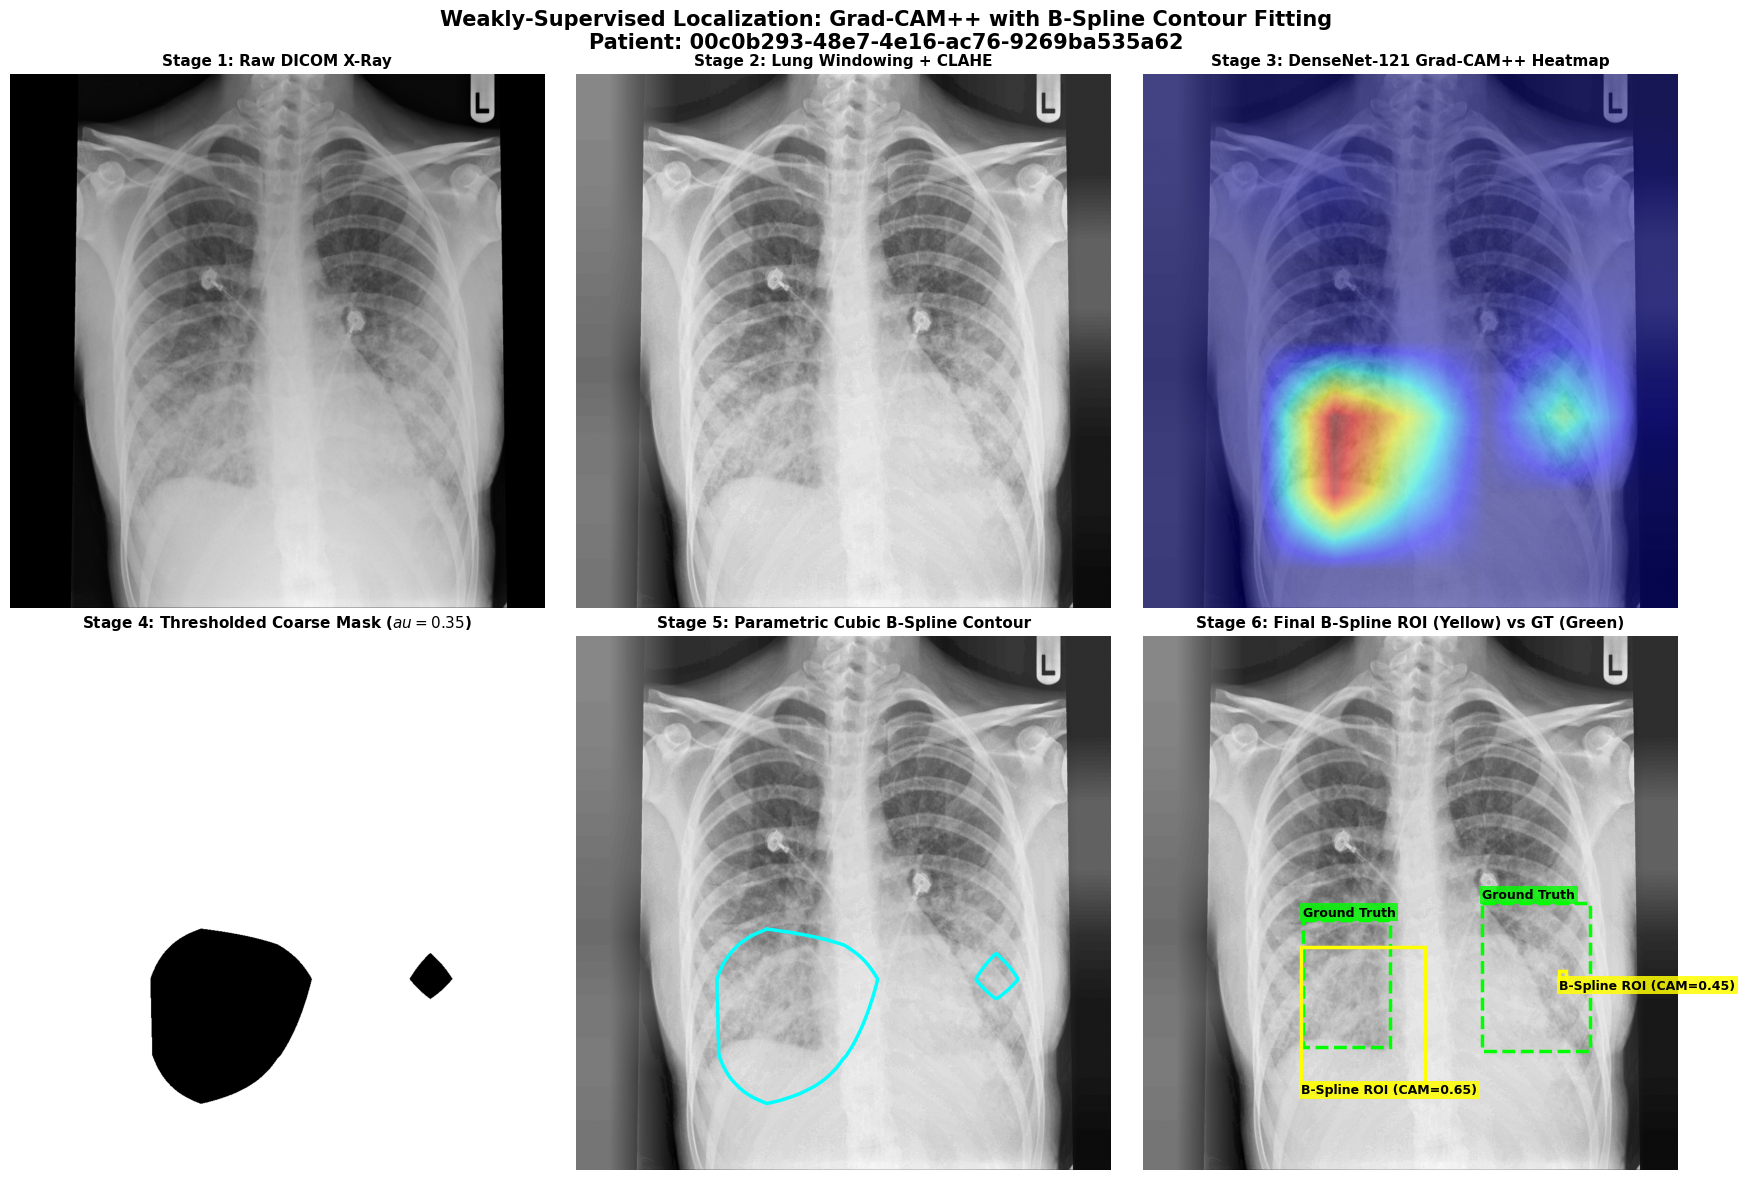

In [32]:
# ── 6-Stage Visualization Gallery ──────────────────────────────────────────
def visualize_6stage_pipeline(patient_id: str, save_filename: Optional[str] = None):
    """
    Displays the complete 6-stage transformation:
    [1] Raw X-ray -> [2] Lung Window -> [3] Grad-CAM++ Heatmap ->
    [4] Threshold Mask -> [5] B-Spline Smooth Contour -> [6] Final Bounding Box vs Ground Truth
    """
    dcm_path = TRAIN_IMG_DIR / f"{patient_id}.dcm"
    img_tensor, raw_1024 = preprocessor(str(dcm_path), target_size=IMG_SIZE)

    # Ground Truth Boxes
    gt_rows = df[(df["patientId"] == patient_id) & (df["Target"] == 1)].dropna(subset=["x", "y", "width", "height"])
    gt_boxes = []
    for _, r in gt_rows.iterrows():
        gt_boxes.append([float(r["x"]), float(r["y"]), float(r["x"] + r["width"]), float(r["y"] + r["height"])])

    # 1. Grad-CAM++ Generation
    cam = gradcam_engine.generate_cam(torch.tensor(img_tensor), method="gradcam++", target_size=1024)

    # 2. B-Spline Optimization
    rois = bspline_engine.optimize_roi(cam, raw_1024)

    # Plot 6 stages
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f"Weakly-Supervised Localization: Grad-CAM++ with B-Spline Contour Fitting\nPatient: {patient_id}", fontsize=15, fontweight="bold")

    # Stage 1: Raw DICOM
    dcm_raw = pydicom.dcmread(str(dcm_path)).pixel_array
    axes[0, 0].imshow(dcm_raw, cmap="gray")
    axes[0, 0].set_title("Stage 1: Raw DICOM X-Ray", fontsize=11, fontweight="semibold")
    axes[0, 0].axis("off")

    # Stage 2: Lung Windowing + CLAHE
    axes[0, 1].imshow(raw_1024, cmap="gray")
    axes[0, 1].set_title("Stage 2: Lung Windowing + CLAHE", fontsize=11, fontweight="semibold")
    axes[0, 1].axis("off")

    # Stage 3: Grad-CAM++ Heatmap
    axes[0, 2].imshow(raw_1024, cmap="gray")
    axes[0, 2].imshow(cam, cmap="jet", alpha=0.50)
    axes[0, 2].set_title("Stage 3: DenseNet-121 Grad-CAM++ Heatmap", fontsize=11, fontweight="semibold")
    axes[0, 2].axis("off")

    # Stage 4: Thresholded Binary Mask
    mask = (cam >= bspline_engine.cam_threshold).astype(np.uint8) * 255
    axes[1, 0].imshow(mask, cmap="binary")
    axes[1, 0].set_title(f"Stage 4: Thresholded Coarse Mask ($\tau={bspline_engine.cam_threshold}$)", fontsize=11, fontweight="semibold")
    axes[1, 0].axis("off")

    # Stage 5: B-Spline Parametric Smooth Contour
    axes[1, 1].imshow(raw_1024, cmap="gray")
    for roi in rois:
        cnt = roi["bspline_contour"]
        axes[1, 1].plot(cnt[:, 0], cnt[:, 1], color="cyan", linewidth=2.5, label="B-Spline Contour")
    axes[1, 1].set_title("Stage 5: Parametric Cubic B-Spline Contour", fontsize=11, fontweight="semibold")
    axes[1, 1].axis("off")

    # Stage 6: Final Bounding Box vs Ground Truth
    axes[1, 2].imshow(raw_1024, cmap="gray")
    for gt in gt_boxes:
        rect_gt = patches.Rectangle((gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1], linewidth=2.5, edgecolor="lime", facecolor="none", linestyle="--")
        axes[1, 2].add_patch(rect_gt)
        axes[1, 2].text(gt[0], max(0, gt[1]-8), "Ground Truth", color="black", fontsize=9, fontweight="bold", bbox=dict(boxstyle="square,pad=0.2", facecolor="lime", alpha=0.8, edgecolor="none"))

    for roi in rois:
        b = roi["bbox"]
        rect_pred = patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=2.5, edgecolor="yellow", facecolor="none", linestyle="-")
        axes[1, 2].add_patch(rect_pred)
        axes[1, 2].text(b[0], min(1010, b[3]+15), f"B-Spline ROI (CAM={roi['mean_cam_intensity']:.2f})", color="black", fontsize=9, fontweight="bold", bbox=dict(boxstyle="square,pad=0.2", facecolor="yellow", alpha=0.85, edgecolor="none"))

    axes[1, 2].set_title("Stage 6: Final B-Spline ROI (Yellow) vs GT (Green)", fontsize=11, fontweight="semibold")
    axes[1, 2].axis("off")

    plt.tight_layout()
    if save_filename:
        out_f = OUTPUT_DIR / save_filename
        plt.savefig(out_f, dpi=150, bbox_inches="tight")
        print(f"✓ Saved 6-stage visualization to: {out_f.resolve()}")
    plt.show()

# Visualize a sample positive patient
sample_pos_id = test_df[test_df["Target"] == 1]["patientId"].iloc[0]
visualize_6stage_pipeline(sample_pos_id, save_filename="stage6_sample_visualization.png")


✓ Saved dual-paradigm visualization to: D:\Downloads\ResNet\DPL302m\gradcam_bspline_results\dual_paradigm_comparison_benchmark.png


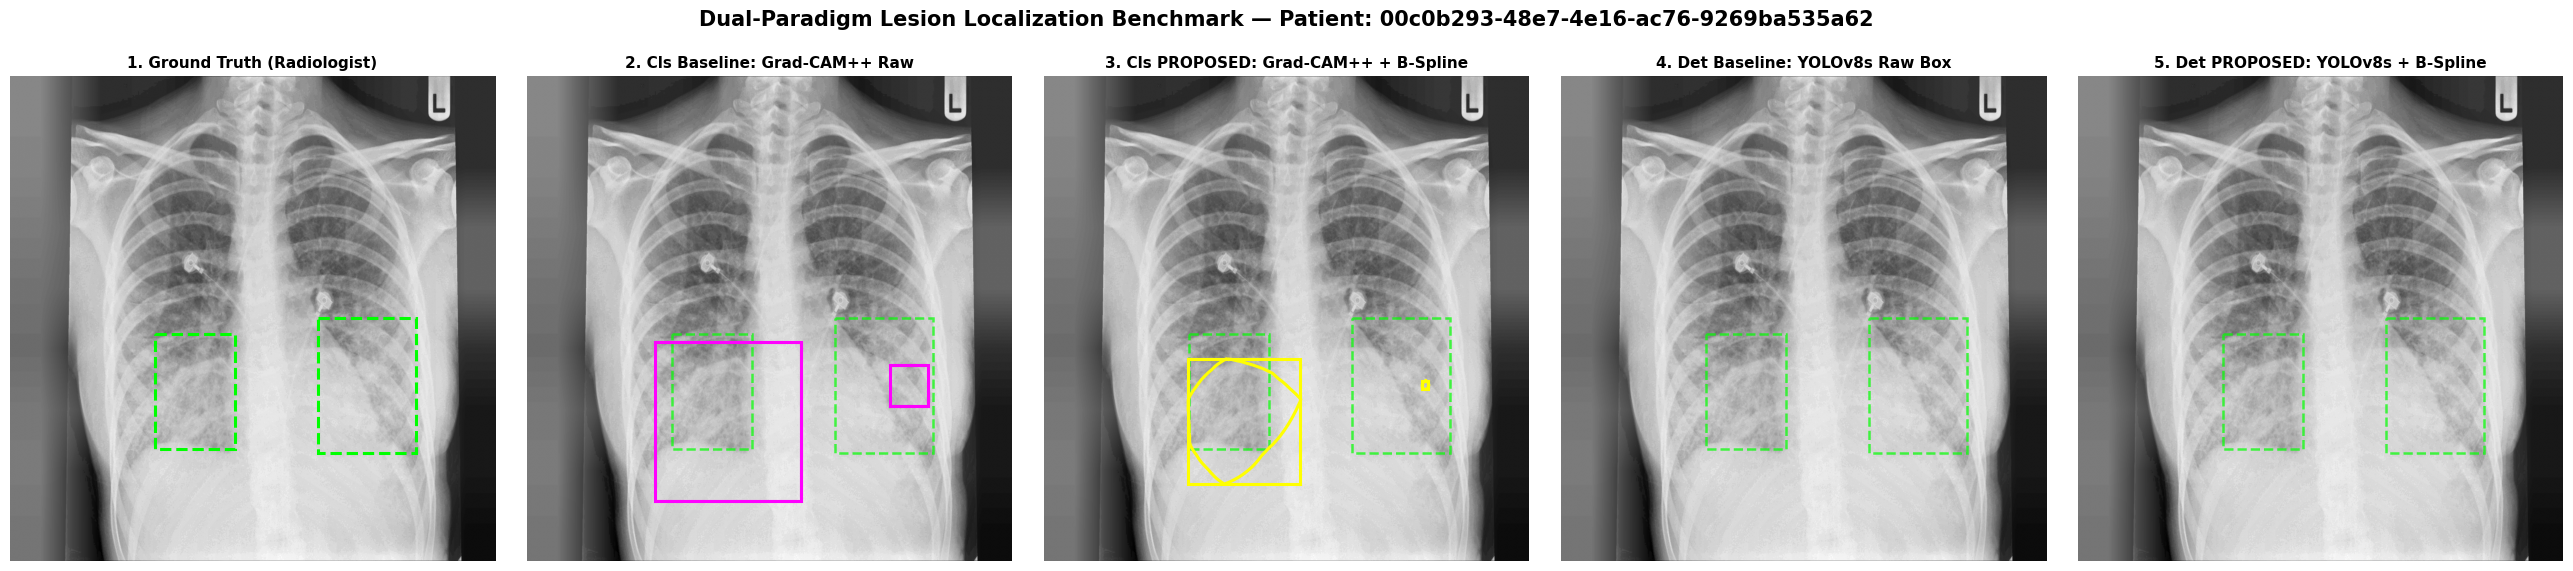

In [33]:
# ── 6-Panel Dual-Paradigm Visual Comparison Gallery ─────────────────────────
def plot_dual_paradigm_comparison(patient_id: str, save_filename: Optional[str] = None):
    """
    Displays a 6-panel clinical visualization comparing both Classification and Detection
    paradigms with and without B-Spline optimization on the same patient.
    """
    dcm_path = TRAIN_IMG_DIR / f'{patient_id}.dcm'
    img_tensor, raw_1024 = preprocessor(str(dcm_path), target_size=IMG_SIZE)
    
    gt_rows = df[(df['patientId'] == patient_id) & (df['Target'] == 1)].dropna(subset=['x', 'y', 'width', 'height'])
    gt_boxes = [[float(r['x']), float(r['y']), float(r['x'] + r['width']), float(r['y'] + r['height'])] for _, r in gt_rows.iterrows()]
    
    # Classification
    cam_plus = gradcam_engine.generate_cam(torch.tensor(img_tensor), method='gradcam++', target_size=1024)
    rois_cls_raw = extract_baseline_rois(cam_plus, method='raw_bbox')
    rois_cls_prop = bspline_engine.optimize_cam_roi(cam_plus, raw_1024)
    
    # Detection
    rois_yolo_raw = extract_yolo_rois(raw_1024, conf_thresh=0.03) if yolo_detector is not None else []
    rois_yolo_prop = []
    for yr in rois_yolo_raw:
        ref_obj = bspline_engine.refine_yolo_bbox(yr['bbox'], raw_1024)
        rois_yolo_prop.append(ref_obj)
    
    panels = [
        ('1. Ground Truth (Radiologist)', raw_1024, gt_boxes, [], 'lime', '--'),
        ('2. Cls Baseline: Grad-CAM++ Raw', raw_1024, [r['bbox'] for r in rois_cls_raw], [r['contour'] for r in rois_cls_raw], 'magenta', '-'),
        ('3. Cls PROPOSED: Grad-CAM++ + B-Spline', raw_1024, [r['bbox'] for r in rois_cls_prop], [r['snake_contour'] for r in rois_cls_prop], 'yellow', '-'),
        ('4. Det Baseline: YOLOv8s Raw Box', raw_1024, [r['bbox'] for r in rois_yolo_raw], [], 'orange', '-'),
        ('5. Det PROPOSED: YOLOv8s + B-Spline', raw_1024, [r['refined_bbox'] for r in rois_yolo_prop], [r['snake_contour'] for r in rois_yolo_prop], 'cyan', '-'),
    ]
    
    n_panels = len(panels)
    fig, axes = plt.subplots(1, n_panels, figsize=(5.2 * n_panels, 5.5))
    fig.suptitle(f'Dual-Paradigm Lesion Localization Benchmark — Patient: {patient_id}', fontsize=15, fontweight='bold', y=1.03)
    
    for i, (title, img, boxes, contours, color, ls) in enumerate(panels):
        axes[i].imshow(img, cmap='gray')
        if i > 0:
            for gt in gt_boxes:
                axes[i].add_patch(patches.Rectangle((gt[0], gt[1]), gt[2]-gt[0], gt[3]-gt[1], linewidth=1.8, edgecolor='lime', facecolor='none', linestyle='--', alpha=0.7))
        for cnt in contours:
            axes[i].plot(cnt[:, 0], cnt[:, 1], color=color, linewidth=2.2)
        for b in boxes:
            axes[i].add_patch(patches.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1], linewidth=2.2, edgecolor=color, facecolor='none', linestyle=ls))
        axes[i].set_title(title, fontsize=11, fontweight='semibold')
        axes[i].axis('off')
    
    plt.tight_layout()
    if save_filename:
        out_p = OUTPUT_DIR / save_filename
        plt.savefig(out_p, dpi=150, bbox_inches='tight')
        print(f'✓ Saved dual-paradigm visualization to: {out_p.resolve()}')
    plt.show()

sample_pos_id = test_df[test_df['Target'] == 1]['patientId'].iloc[0]
plot_dual_paradigm_comparison(sample_pos_id, save_filename='dual_paradigm_comparison_benchmark.png')
